# Control Charts for Multiple Stream Processes
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Boyd's Group Control Chart](#boyds-group-control-chart)
3. [Worked Example: Car Wash Wax Usage](#worked-example-car-wash-wax-usage)
4. [Limitations of Boyd's GCC](#limitations-of-boyds-gcc)
5. [A Control Chart for Each Stream Approach](#a-control-chart-for-each-stream-approach)
6. [Worked Example: Control Chart for Each Stream](#worked-example-control-chart-for-each-stream)
7. [Final Remarks](#final-remarks)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-10-Multiple-Stream-Processes")

## Introduction

By now you've seen a lot of different control charts, each built for a specific situation. Most recently, we covered **multivariate** control charts (Hotelling's $T^2$ and the MEWMA chart) for jointly monitoring several processes when we assume some **degree of correlation** between them.

There's a related but distinct scenario: monitoring several *parallel* processes that we generally assume are **independent** of each other, but which all share the same target value. Picture a bolt factory large enough to run several identical machines side by side, all manufacturing the same bolt. We'd expect the target diameter to be identical across every machine. However, each machine is its own process, not correlated with the others the way, say, a bearing's inner and outer diameter would be.

This setup is called a **Multiple Stream Process (MSP)**, and it shows up constantly in modern operations: parallel filling lines, redundant servers behind a load balancer, multiple call center locations handling the same type of request, or — as in today's example — several car washes all using the same brand of hot wax. Charts built for MSPs generally assume independence between streams, in contrast to the multivariate charts we just covered. Traditional MSP charts are variations on the Shewhart $\bar{X}$ chart, so, same as always, they're meant for a quantitative, continuous quality characteristic.

## Boyd's Group Control Chart

Boyd (1950) proposed the first, and still most commonly used, MSP control chart, built directly on top of the $\bar{X}$ chart. Suppose we have $s$ streams. In Phase I, exactly as with the ordinary $\bar{X}$ chart, we take $m$ samples of size $n$ from **each** stream to calculate the control limits. At each time point, for each stream, we compute a sample mean and a sample range.

We then use the grand mean and the overall mean range, just like before, and the control limits are calculated exactly as they would be for a univariate process:

$$ UCL = \bar{\bar{x}} + A_2\bar{R} $$
$$ LCL = \bar{\bar{x}} - A_2\bar{R} $$

where $A_2$ is the familiar control charting constant, indexed by sample size $n$.

### The twist: what actually gets plotted

The key difference between Boyd's Group Control Chart (GCC) and an ordinary $\bar{X}$ chart is the plotting statistic. Instead of plotting a single sample mean, at each time point we plot **both the minimum and maximum** sample mean observed *across all streams*. If either one exceeds the control limits, that's an out-of-control signal, for the group as a whole.

## Worked Example: Car Wash Wax Usage

Suppose we own several car washes across Cobb County, and we want to monitor the amount of liquid hot wax used (in gallons) per day at each of our five locations. We take a random sample of $n=5$ days from each of the previous $m=25$ weeks, at each of our $s=5$ locations, and want to build a GCC. Data live in `CarWash.xlsx`.

In [2]:
## Load the Libraries ##

library(tidyverse)
library(readxl)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


### Read in the Car Wash data

In [3]:
## Car Wash Example ##

carwash <- read_xlsx("CarWash.xlsx")

carwash |>
  glimpse()

Rows: 125
Columns: 6
$ Day1      <dbl> 48, 57, 34, 55, 38, 57, 46, 52, 45, 55, 69, 68, 30, 62, 49, 73, 52, 45, 33, 35, 52, 52, 28, 55, 50, 35, 46, 65, 56…
$ Day2      <dbl> 54, 56, 54, 47, 43, 44, 47, 61, 56, 44, 44, 52, 55, 63, 44, 65, 63, 45, 42, 47, 59, 46, 50, 40, 39, 50, 56, 66, 71…
$ Day3      <dbl> 70, 57, 57, 43, 55, 54, 58, 61, 51, 52, 62, 55, 60, 39, 34, 34, 49, 48, 53, 47, 54, 45, 30, 42, 65, 54, 45, 60, 46…
$ Day4      <dbl> 33, 63, 41, 43, 49, 54, 49, 38, 46, 71, 55, 57, 61, 67, 61, 62, 38, 59, 57, 56, 51, 70, 44, 46, 45, 36, 40, 40, 58…
$ Day5      <dbl> 45, 51, 49, 31, 51, 63, 36, 54, 60, 61, 56, 48, 53, 37, 41, 63, 43, 65, 49, 46, 43, 55, 49, 37, 55, 46, 42, 57, 48…
$ CarWashID <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …


### Calculate the sample means and ranges for each stream/week

Each row represents one car wash location in one week; the daily wax-usage columns need to be summarized into a mean and a range per row, with the `CarWashID` and `Week` carried along for grouping later.

In [5]:
## Boyd's Group Control Chart ##

## Obtain Sample Means & Ranges ##

## Dataframe for Sample Means ##

wax_means <- tibble(Means = rowMeans(carwash[,-6]), # removing CarWashID from the calculation
                    CarWashID = carwash$CarWashID, # adding CarWashID back in
                    Week = rep(1:25,5)) # adding a week column

wax_means |>
  glimpse()

Rows: 125
Columns: 3
$ Means     <dbl> 50.0, 56.8, 47.0, 43.8, 47.2, 54.4, 47.2, 53.2, 51.6, 56.6, 57.2, 56.0, 51.8, 53.6, 45.8, 59.4, 49.0, 52.4, 46.8, …
$ CarWashID <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ Week      <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 1, 2, 3, 4, 5, 6, 7, 8,…


In [6]:
## Dataframe for Sample Ranges ##

wax_ranges <- tibble(Ranges = 
                       apply(carwash[,-6],1,FUN=function(x){
                         
                         max(x) - min(x)
                         
                         }), # calculating the range for each row
                     CarWashID = carwash$CarWashID, # adding CarWashID back in
                     Week = rep(1:25,5) # adding a week column
              )

wax_ranges |>
  glimpse()

Rows: 125
Columns: 3
$ Ranges    <dbl> 37, 12, 23, 24, 17, 19, 22, 23, 15, 27, 25, 20, 31, 30, 27, 39, 25, 20, 24, 21, 16, 25, 22, 18, 26, 19, 16, 26, 25…
$ CarWashID <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, …
$ Week      <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 1, 2, 3, 4, 5, 6, 7, 8,…


### Calculate the grand mean, mean range, and control limits

In [7]:
## Calculate the Grand Mean ##

xdbar <- mean(wax_means$Means)

rbar <- mean(wax_ranges$Ranges)

In [8]:
## Control Limits ##

A2 <- 0.577

UCL <- xdbar + A2*rbar

LCL <- xdbar - A2*rbar

### Extract the min/max stream mean at each time point

This is the step that makes Boyd's GCC distinctive. Instead of plotting every stream's mean separately, we collapse each week down to just its most extreme values.

In [9]:
## Obtain Minimum and Maximum Mean Values for Each Car Wash ##

max_means <- wax_means |>
  group_by(Week) |>
  summarize(Max = max(Means),
            Min = min(Means))

### Plot the Phase I chart

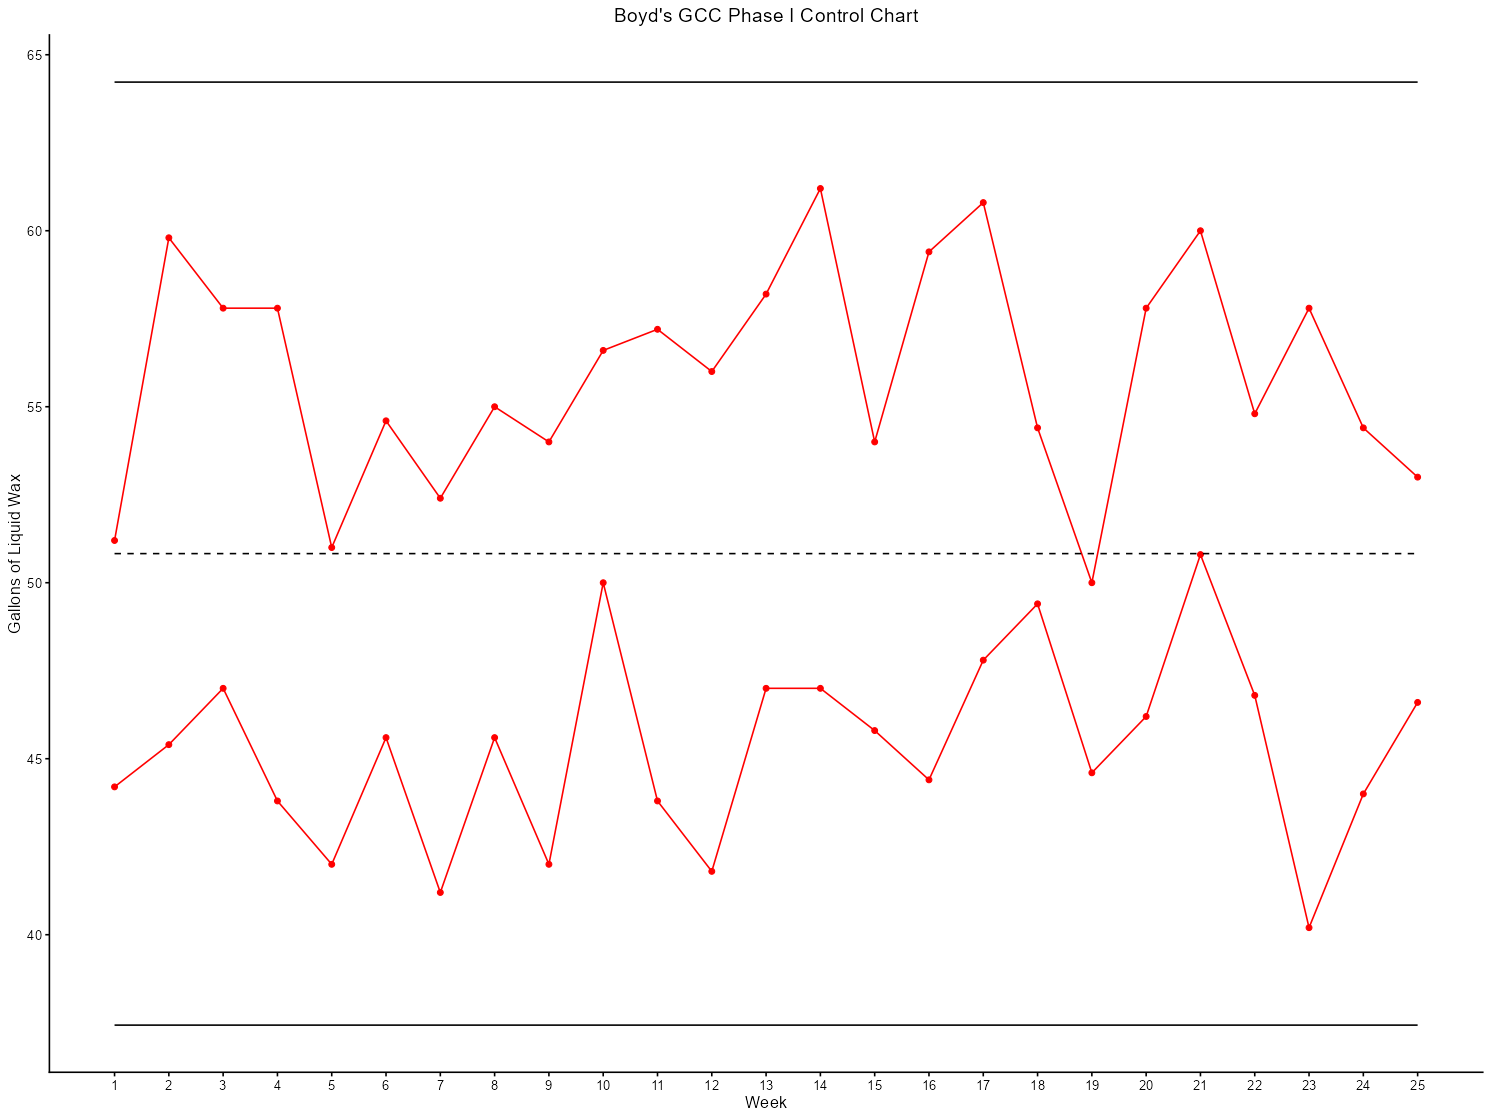

In [10]:
## Plot Phase I Chart ##

max_means |>
  ggplot(aes(x=Week)) + 
  geom_line(aes(y=UCL),color="black") +
  geom_line(aes(y=LCL),color="black") +
  geom_line(aes(y=Max),color="red") +
  geom_line(aes(y=Min),color="red") +
  geom_point(aes(y=Max),color="red") +
  geom_point(aes(y=Min),color="red") +
  geom_line(aes(y=xdbar),color="black",linetype="dashed") +
  labs(x = "Week", 
       y = "Gallons of Liquid Wax",
       title = "Boyd's GCC Phase I Control Chart") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.50)) +
  scale_x_continuous(breaks = seq(1,25))

Phase I shows evidence of statistical control, so we're ready to move to Phase II.

### Phase II: applying the finalized limits to new data

In [11]:
## Okay, great! It looks like our Phase I analysis shows evidence of 
## statistical control, so let's move on to Phase II analysis ##

carwash2 <- read_xlsx("CarWash.xlsx",sheet=2)

In [12]:
## Obtain Sample Means & Ranges ##

wax_means2 <- tibble(Means = rowMeans(carwash2[,-6]),
                     CarWashID = carwash2$CarWashID,
                     Week = rep(1:25,5))

In [13]:
wax_ranges2 <- tibble(Ranges = 
                        apply(carwash2[,-6],1,FUN=function(x){
                          
                          max(x) - min(x)
                          
                        }),
                      CarWashID = carwash2$CarWashID,
                      Week = rep(1:25,5)
)

In [14]:
## Obtain Minimum and Maximum Mean Values ##

max_means2 <- wax_means2 |>
  group_by(Week) |>
  summarize(Max = max(Means),
            Min = min(Means))

### Plot the Phase II chart

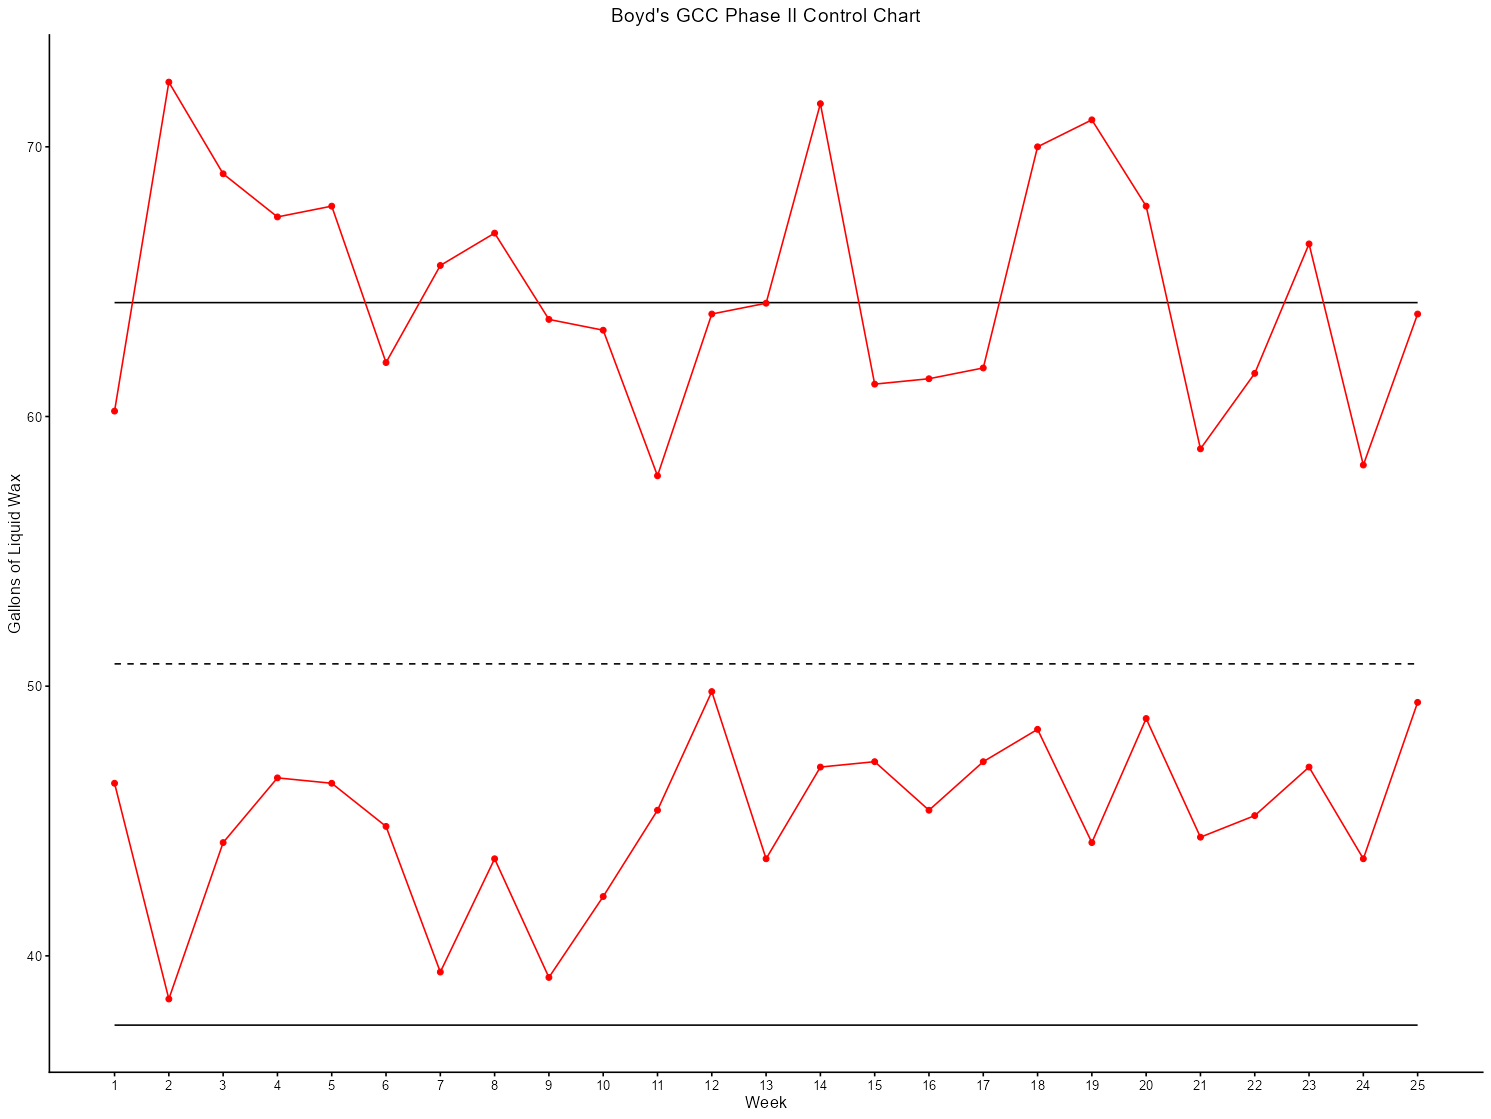

In [15]:
## Plot Phase II Chart ##

max_means2 |>
  ggplot(aes(x=Week)) + 
  geom_line(aes(y=UCL),color="black") +
  geom_line(aes(y=LCL),color="black") +
  geom_line(aes(y=Max),color="red") +
  geom_line(aes(y=Min),color="red") +
  geom_point(aes(y=Max),color="red") +
  geom_point(aes(y=Min),color="red") +
  geom_line(aes(y=xdbar),color="black",linetype="dashed") +
  labs(x = "Week", 
       y = "Gallons of Liquid Wax",
       title="Boyd's GCC Phase II Control Chart") +
  theme_classic() +
  theme(plot.title=element_text(hjust=0.50)) +
  scale_x_continuous(breaks = seq(1,25))

We've got some points plotting above the $UCL$. However, Boyd's GCC only tells us *that* the group with the maximum valued mean is out of control, but not if others are also OOC.

In [16]:
## Okay, it looks like we have some points plotting above the UCL...
## but which stream is causing it? ##

## Violations ##

violations <- wax_means2 |>
  filter(Means > UCL | Means < LCL)

print(violations)

# A tibble: 11 × 3
   Means CarWashID  Week
   <dbl>     <dbl> <int>
 1  72.4         1     2
 2  69           1     3
 3  67.4         1     4
 4  67.8         1     5
 5  65.6         1     7
 6  66.8         1     8
 7  71.6         1    14
 8  70           1    18
 9  71           1    19
10  67.8         1    20
11  66.4         1    23


Car Wash 1 is the culprit. That extra filtering step we just did — going back to the raw per-stream means after the group chart flagged a problem — is really a workaround for one of Boyd's GCC's core limitations, which we'll get to next.

## Limitations of Boyd's GCC

Boyd's GCC has some fairly significant drawbacks:

1. **May not scale well** as the number of streams $s$ gets large
2. **Only uses two data points** per time period (the min and max) — everything in between is discarded
3. **Non-normal plotting statistics** — the minimum and maximum of a sample don't follow the same distribution as the underlying variable (order statistics rarely do)
4. **Runs rules don't apply cleanly** — the usual pattern-based signals we rely on for ordinary $\bar{X}$ charts aren't straightforward to use here
5. **Serious ARL degradation with non-normal data** — [Brown and Schaffer (2020)](https://www.tandfonline.com/doi/abs/10.1080/03610926.2020.1738492) documented substantial deterioration in $ARL_1$ performance under non-normality

That second point is exactly what we ran into above: the group chart told us *something* was wrong, but we had to dig back into the raw stream-level data ourselves to identify Car Wash 1 and Car Wash 1 alone as the actual culprit. That's a real usability gap. This is exactly the motivation for the next approach.

## A Control Chart for Each Stream Approach

Other MSP control charts have been developed over the years (e.g., [Mortell and Runger, 1995](https://www.tandfonline.com/doi/abs/10.1080/00224065.1995.11979554); [Alt and Montgomery, 1996](https://www.tandfonline.com/doi/abs/10.1080/00207549608905074); [Epprecht et al., 2011](https://www.scielo.br/j/prod/a/QFwK6TjGjqbWw3HfbBBspKN/?format=pdf&lang=en); [Vincenten et al., 2018](https://www.emerald.com/ijqrm/article-abstract/35/2/335/141773/Monitoring-process-control-chart-with-finite?redirectedFrom=fulltext&casa_token=HbBUDUQMww4AAAAA:9uGiDJKj8F2z8L1KkLSXbjX404YkJ9HlfQbyvkI4kvEvLPMgwXXm9M-iN5qmNVCPIH1fLhODlcPySu5V)), but the most straightforward, and arguably most practical, is the approach suggested by [Mences et al. (2008)](https://www.tandfonline.com/doi/abs/10.1080/08982110701241608): **just build a control chart for each stream.**

The reasoning is refreshingly modern: the classic argument against per-stream charts was that maintaining $s$ separate charts by hand doesn't scale. But nearly all control charting today is done via computer anyway (exactly the kind of workflow we've been building all semester) so that objection carries a lot less weight than it did in Boyd's era.

This approach also allows each stream to have a **different** target $\mu_0$ if appropriate, and it accounts for the multiple-comparisons problem baked into monitoring $s$ streams simultaneously by adjusting the control limits based on the inter-stream correlation. Otherwise, everything we already know from the Shewhart $\bar{X}$ chart carries over directly — the correlation adjustment is really the only new ingredient.

## Worked Example: Control Chart for Each Stream

Let's redo the car wash example using this approach instead. First, we split the Phase I data by `CarWashID` so each stream has its own dataframe.

In [17]:
## A Control Chart for Each Stream Approach ##

## Split up Phase I Data by CarWashID ##

p1 <- split(carwash,carwash$CarWashID)

`p1` is now a list, with one dataframe per car wash. Next, we calculate the sample means and ranges for each stream, exactly as before — just organized per-stream instead of pooled together.

In [18]:
## Now, p1 is a list where each element of the list is a dataframe -- 
## one for each carwash ##

## Calculate Means & Ranges ##

samp_list <- lapply(p1,FUN=function(x){
  
  df <- tibble(Means = rowMeans(x[,-6]),
               Ranges = 
                 apply(x[,-6],1,FUN=function(x){
                   
                   max(x) - min(x)
                   
                 }),  
                CarWashID = x$CarWashID,
                Week = seq(1,25))
  
  return(df)
  
})

### Calculating stream-specific control limits with the correlation adjustment

Here's the one genuinely new ingredient: instead of the ordinary $A_2\bar{R}$-based limits, we use a correlation-adjusted multiplier $L$ from the Mences et al. (2008) reference table, combined with the $d_2$ constant. Assuming (as we are here) zero correlation between streams, and monitoring 5 streams, the appropriate value is $L = 3.46$.

In [19]:
## Calculate Control Limits & Plot Charts ##

library(IQCC)

d2 <- d2(5)

L <- 3.46

Loading required package: miscTools


### Building each stream's Phase I chart

We loop over each car wash, calculate its own center line and control limits, plot its chart, and record any violations — all in a single pass.

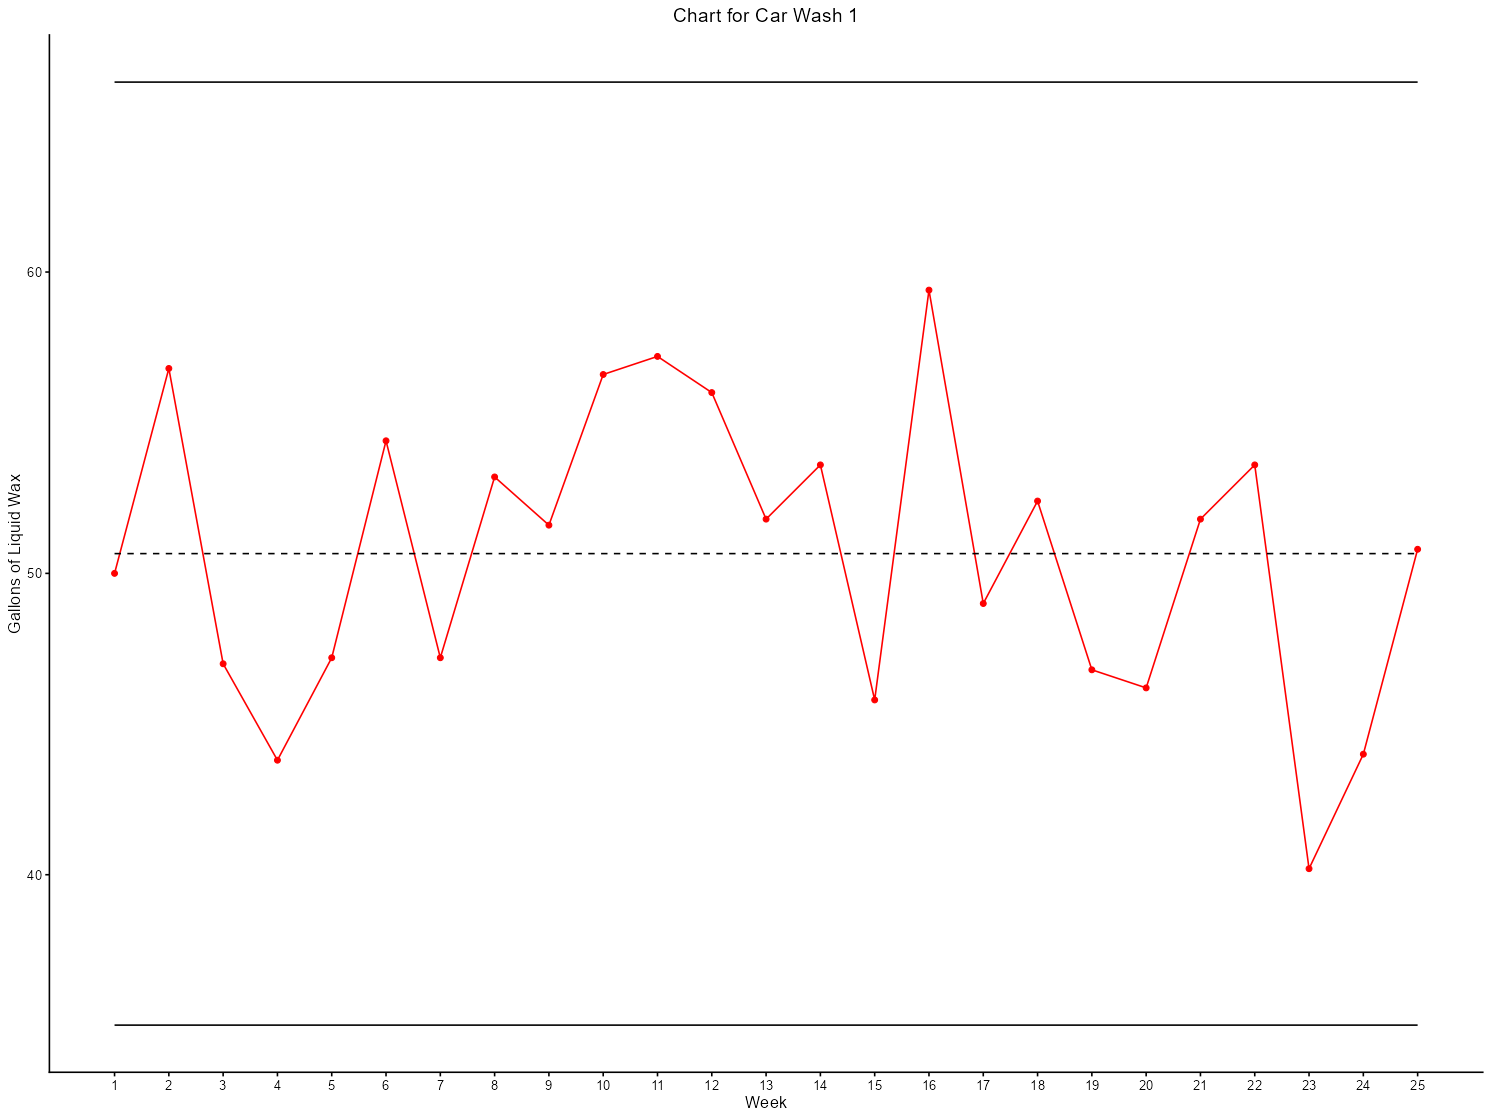

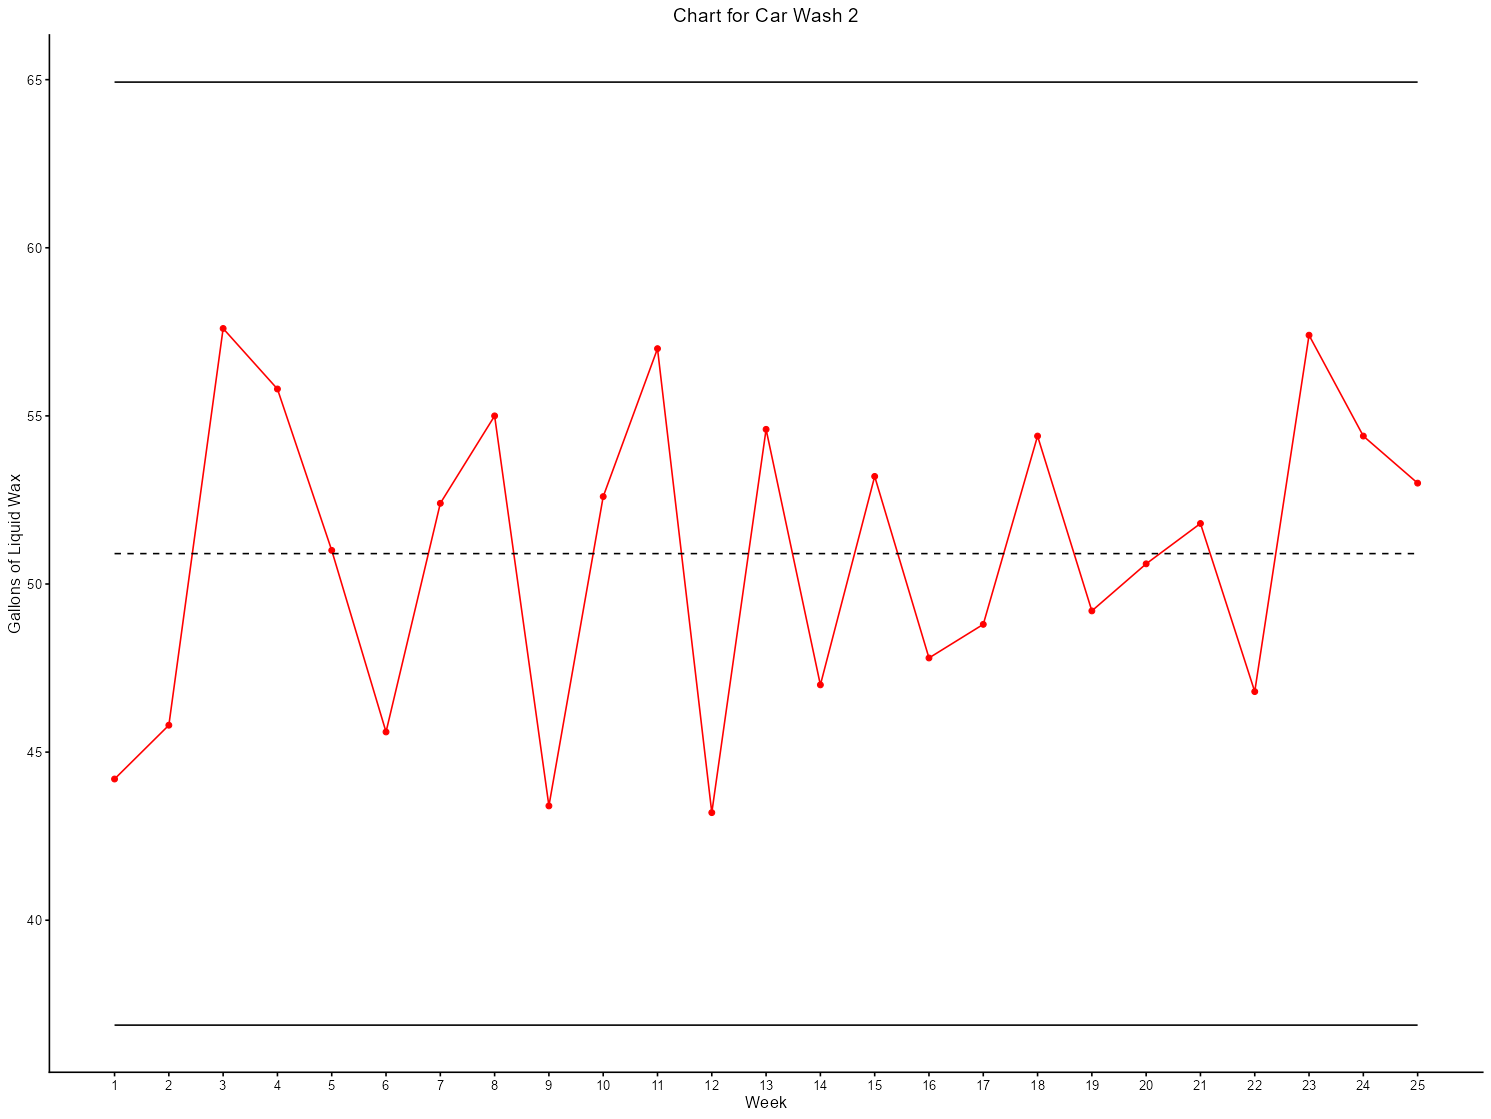

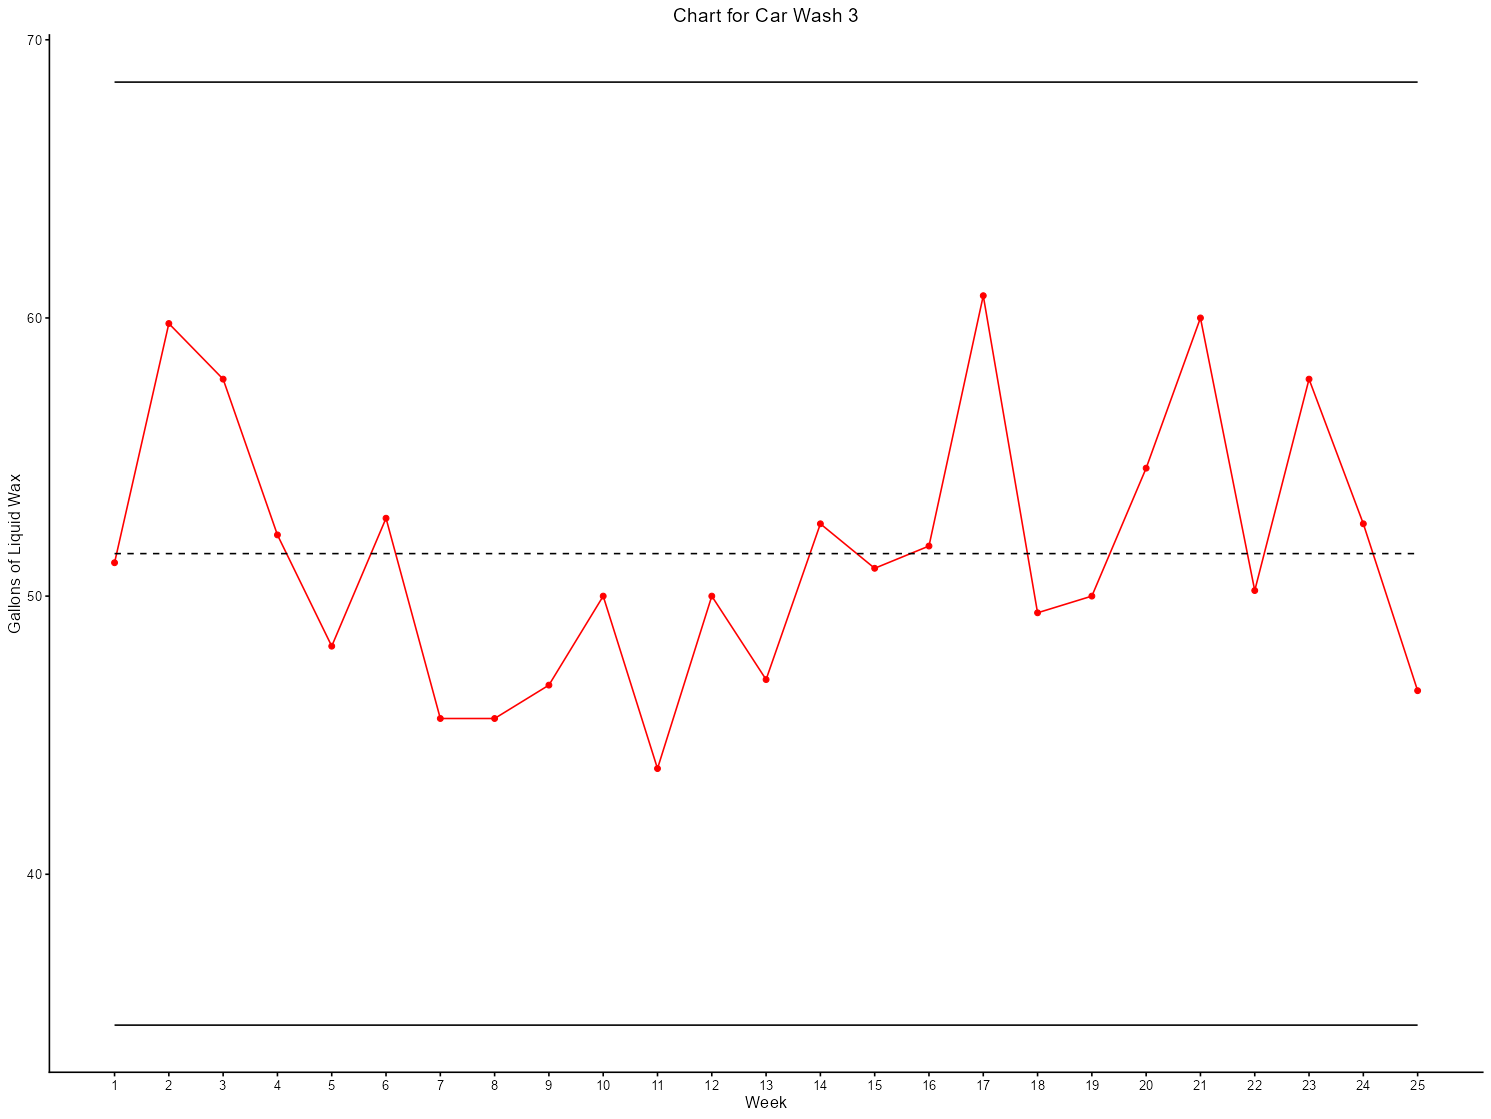

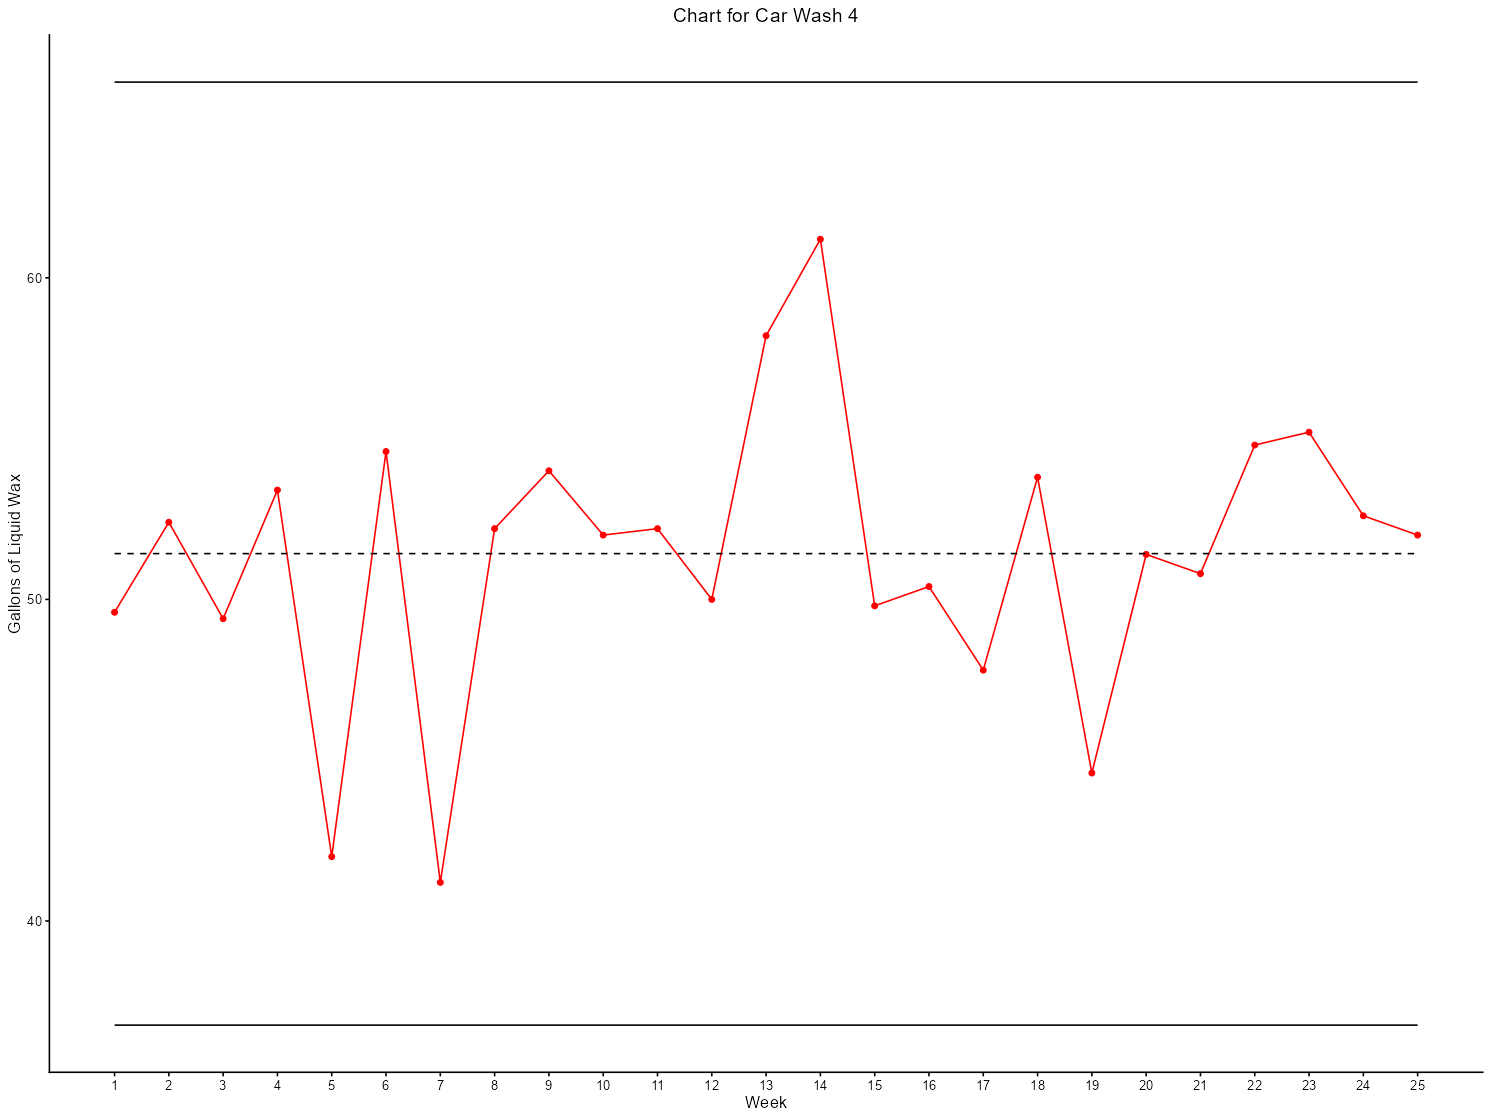

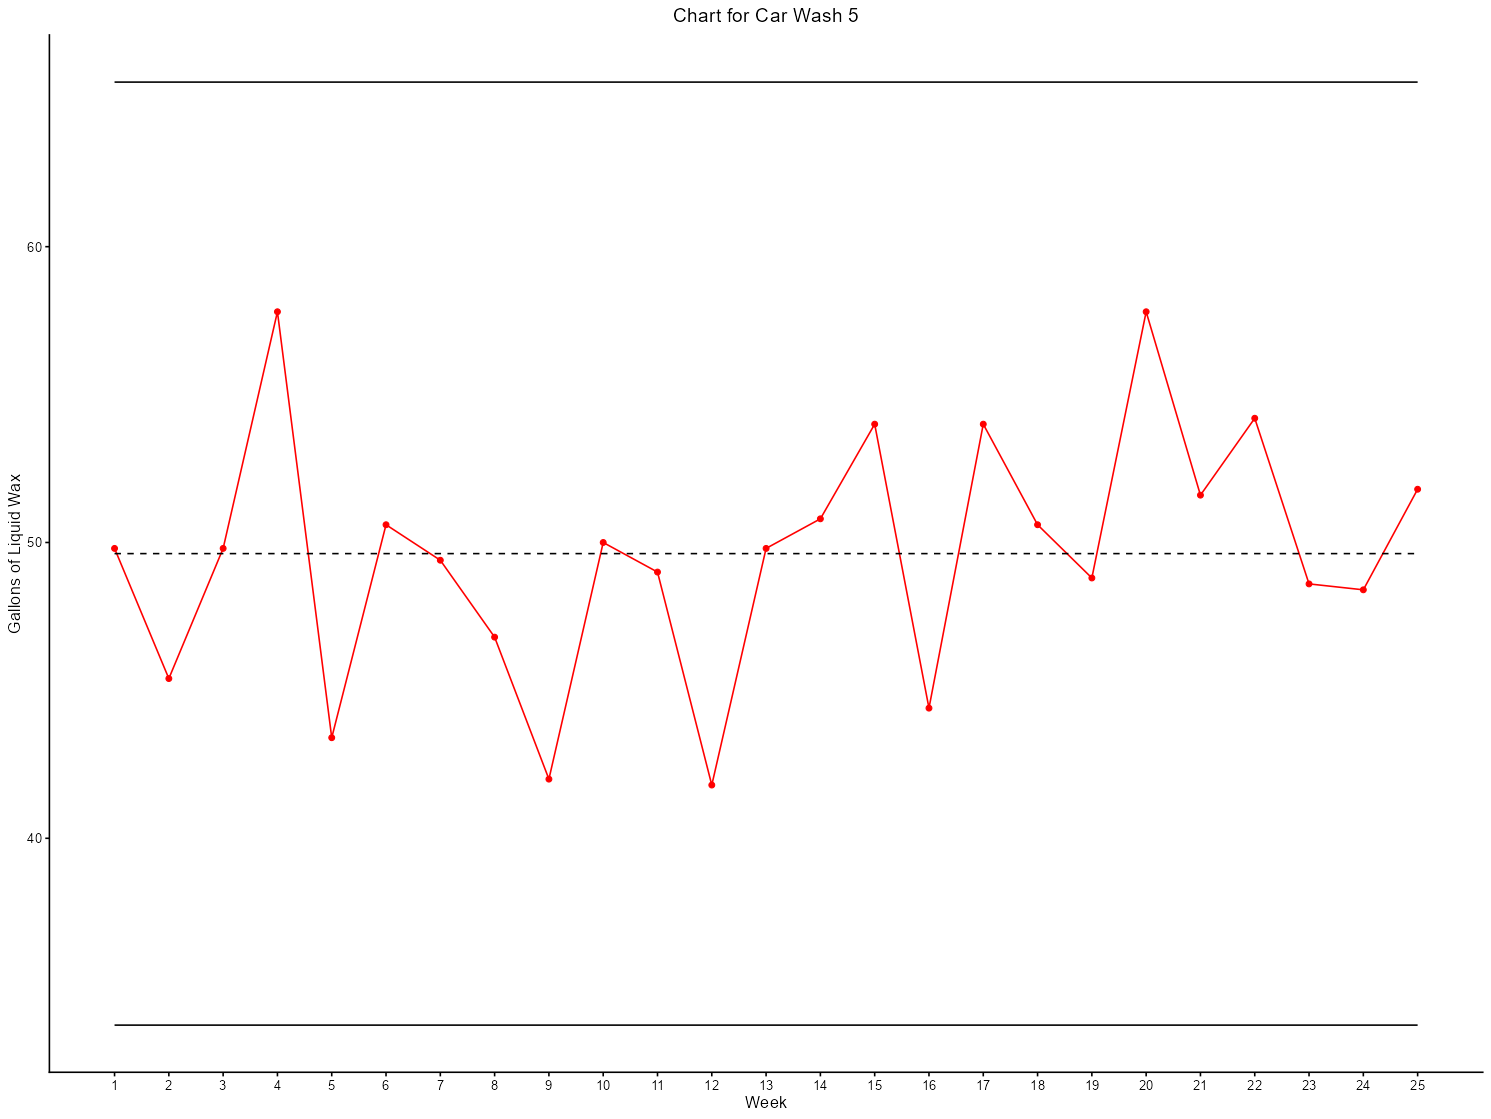

In [20]:
## Notice in the article for the Control Chart for Each Stream Technique,
## in Table 3, if we assume that the correlation between each stream is 0,
## which is what we're doing in this example, then the L value we use for
## the control limits when the number of monitored streams is 5 is 3.46 ##

cfes <- lapply(samp_list,FUN=function(x){
  
  xdbar <- mean(x$Means)
  
  rbar <- mean(x$Ranges)
  
  UCL <- xdbar + L*rbar/(d2*sqrt(5))
  
  LCL <- xdbar - L*rbar/(d2*sqrt(5))
  
  p1_chart <- x |>
    ggplot(aes(x=Week,y=Means)) +
    geom_point(color='red') + geom_line(color='red') +
    geom_line(aes(y=UCL),color='black') +
    geom_line(aes(y=LCL),color='black') +
    geom_line(aes(y=xdbar),color='black',linetype='dashed') +
    labs(x = "Week", y = "Gallons of Liquid Wax",
         title = paste("Chart for Car Wash ",x$CarWashID,sep="")) +
    theme_classic()  +
    theme(plot.title=element_text(hjust=0.50)) +
    scale_x_continuous(breaks = seq(1,25))
  
  info <- list(Center = xdbar,
               Limits = c(LCL,UCL),
               Violations = x |>
                 filter(Means > UCL | Means < LCL) |>
                 select(Week))
  
  print(p1_chart)
  
  return(info)
  
})

Each stream's Phase I data plots in control, so we're ready to bring these per-stream centers and limits forward into Phase II — the same idea as before, just repeated five times instead of once.

### Phase II: applying each stream's finalized limits

In [21]:
## Phase II Analysis ##

## Split up Phase II Data by CarWashID ##

p2 <- split(carwash2,carwash2$CarWashID)

In [22]:
## Calculate Means ##

samp_list2 <- lapply(p2,FUN=function(x){
  
  df <- tibble(Means = rowMeans(x[,-6]),
               Ranges = 
                 apply(x[,-6],1,FUN=function(x){
                   
                   max(x) - min(x)
                   
                 }),  
               CarWashID = x$CarWashID,
               Week = seq(1,25))
  
  return(df)
  
})

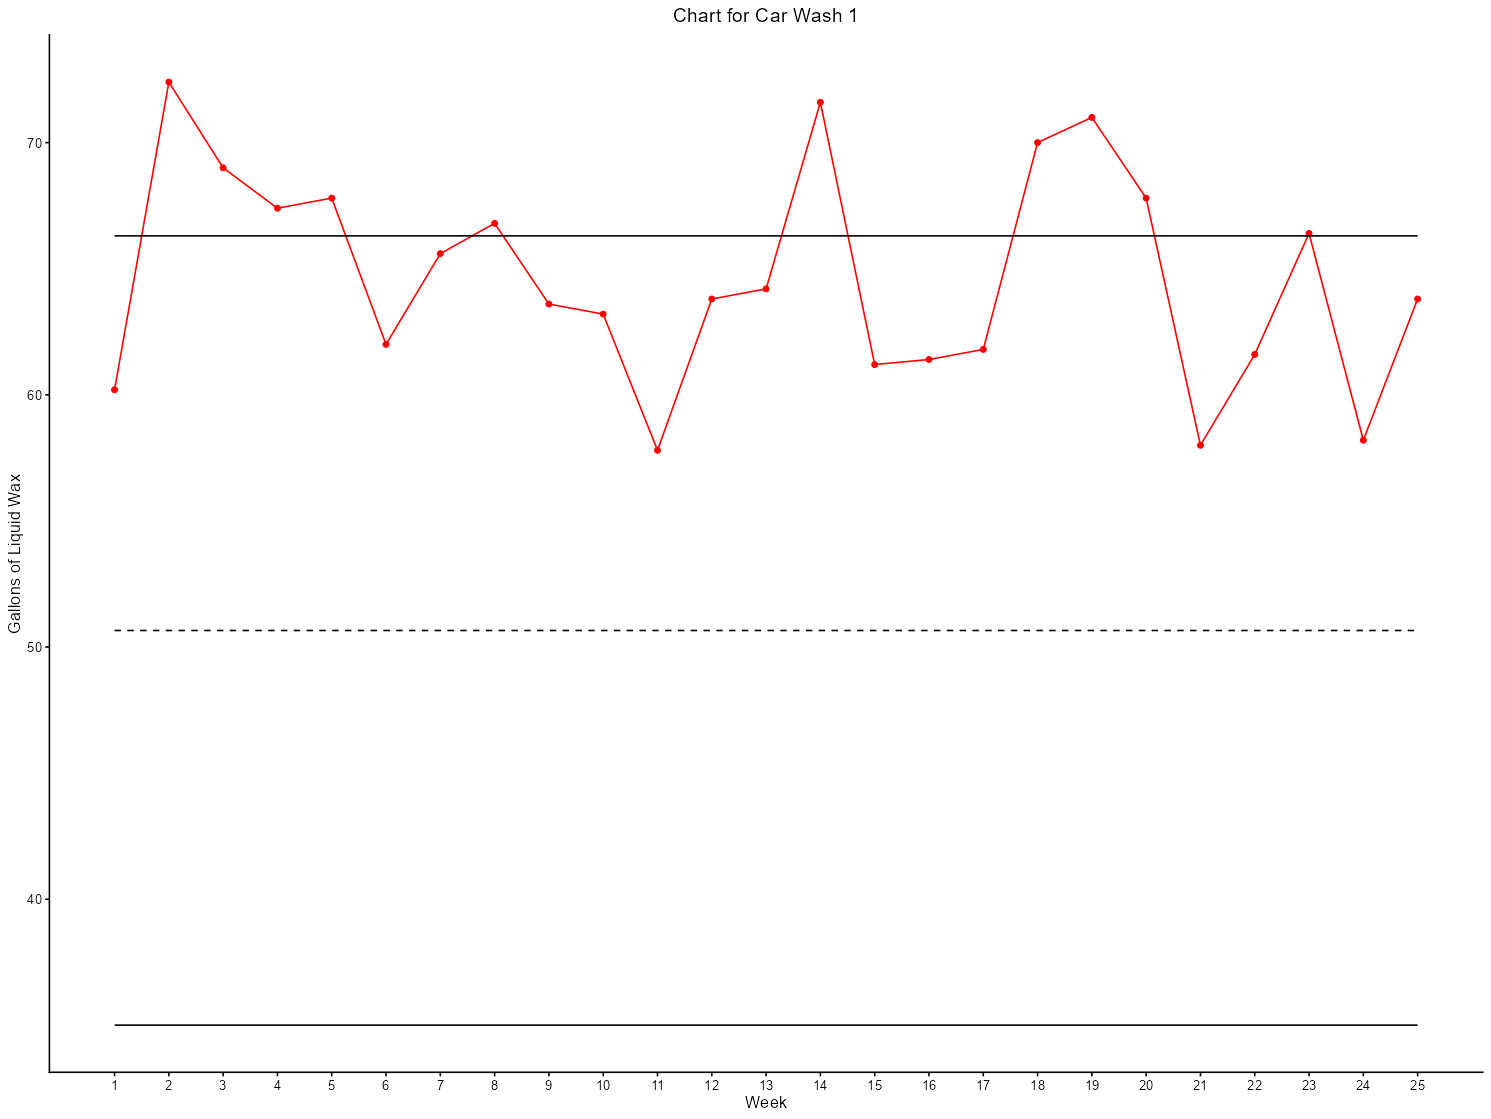

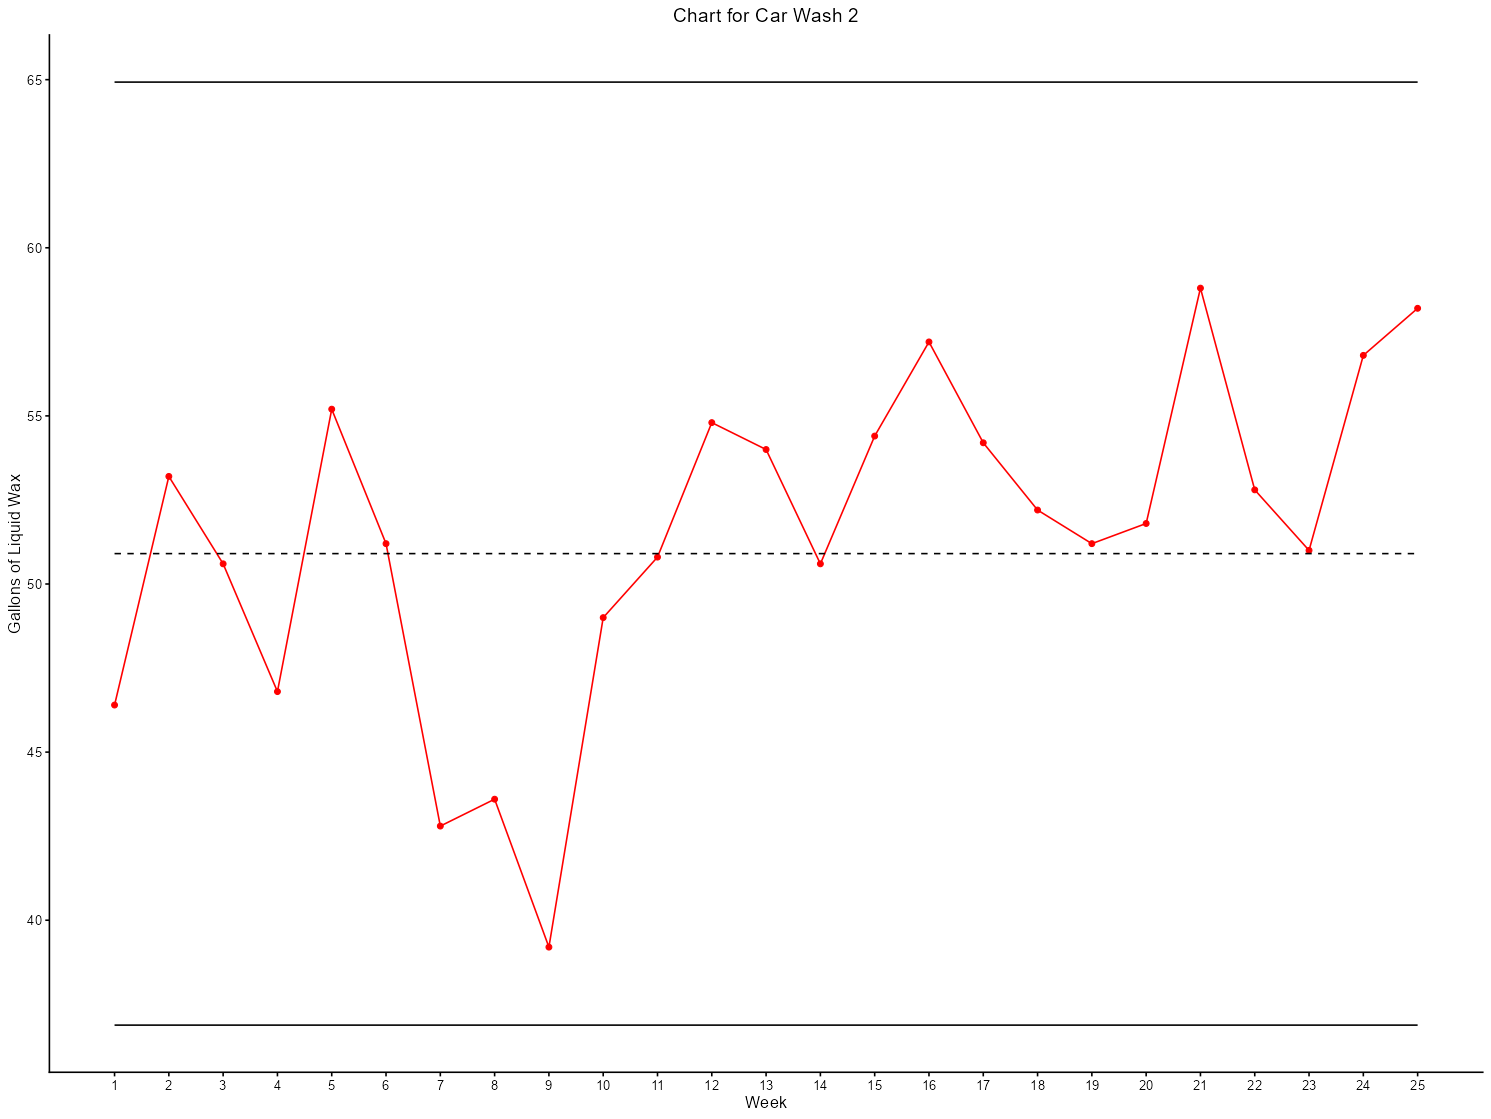

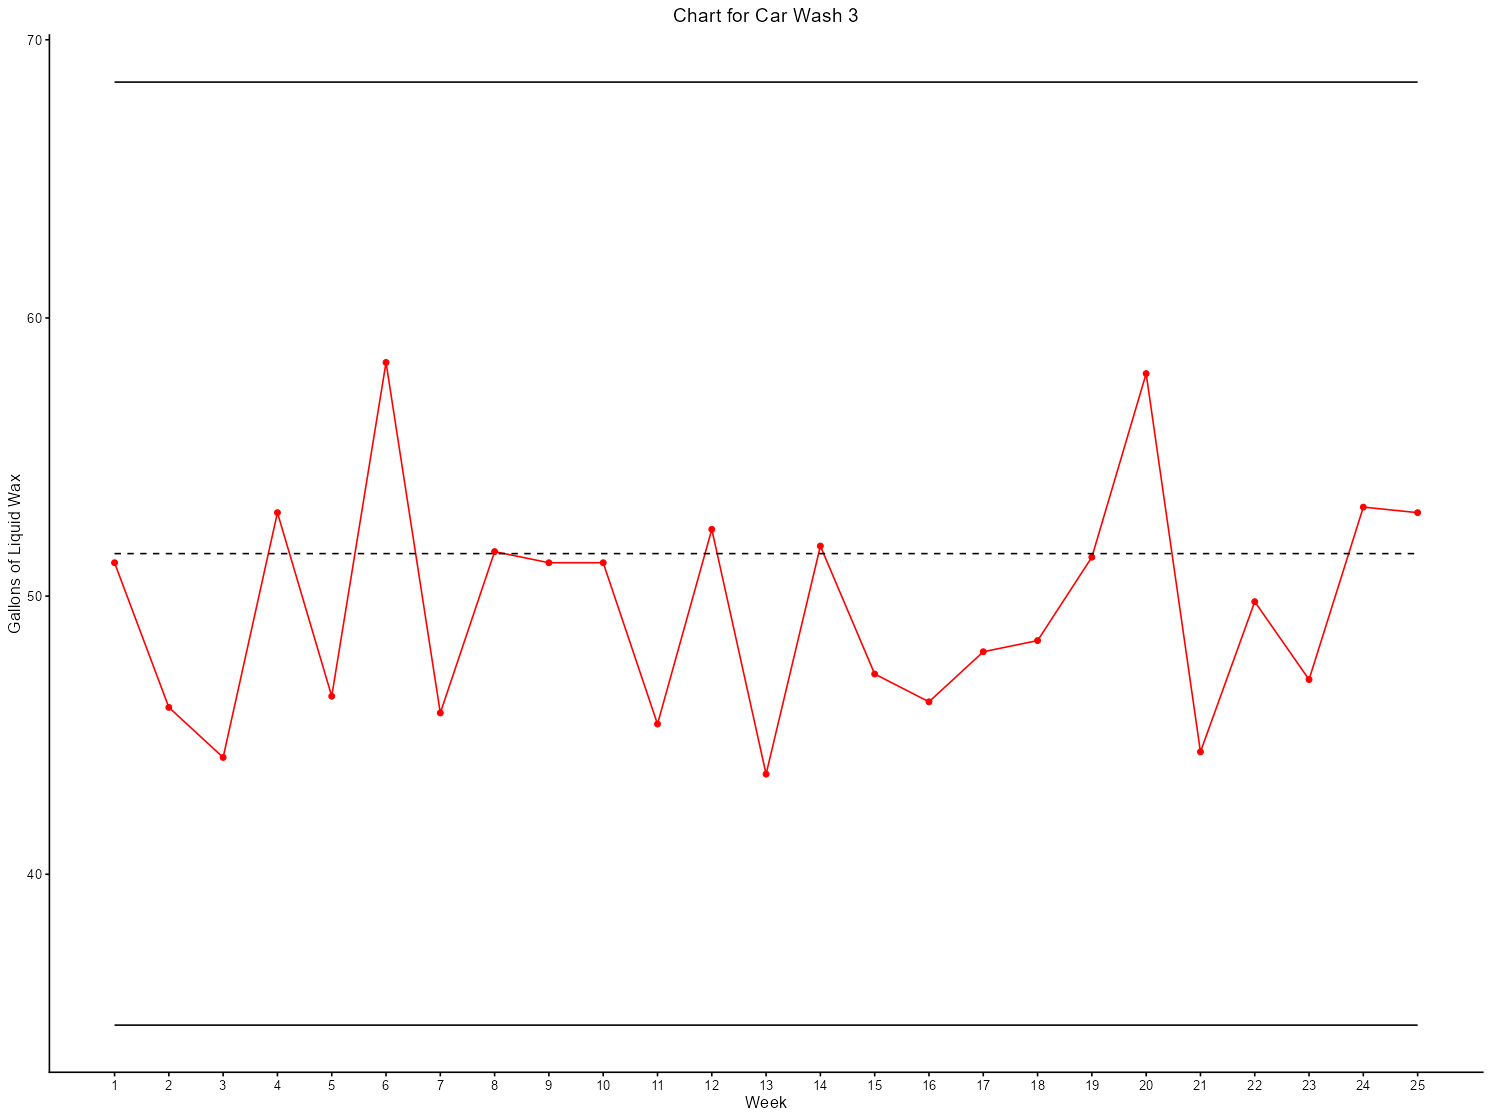

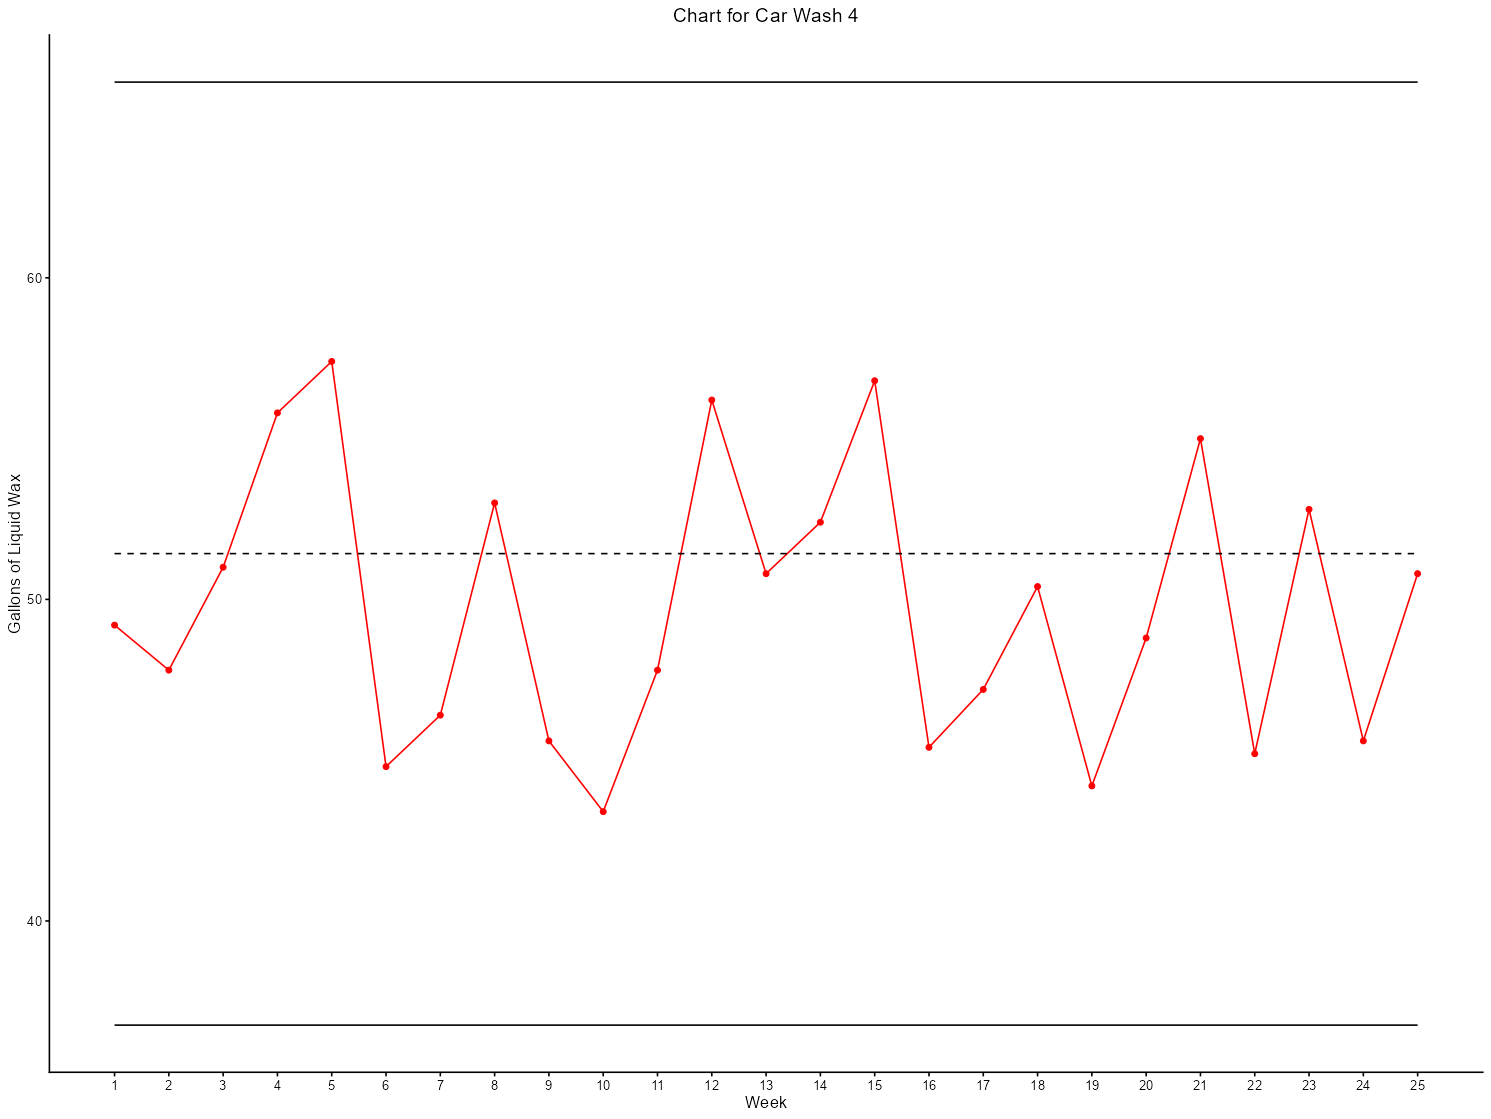

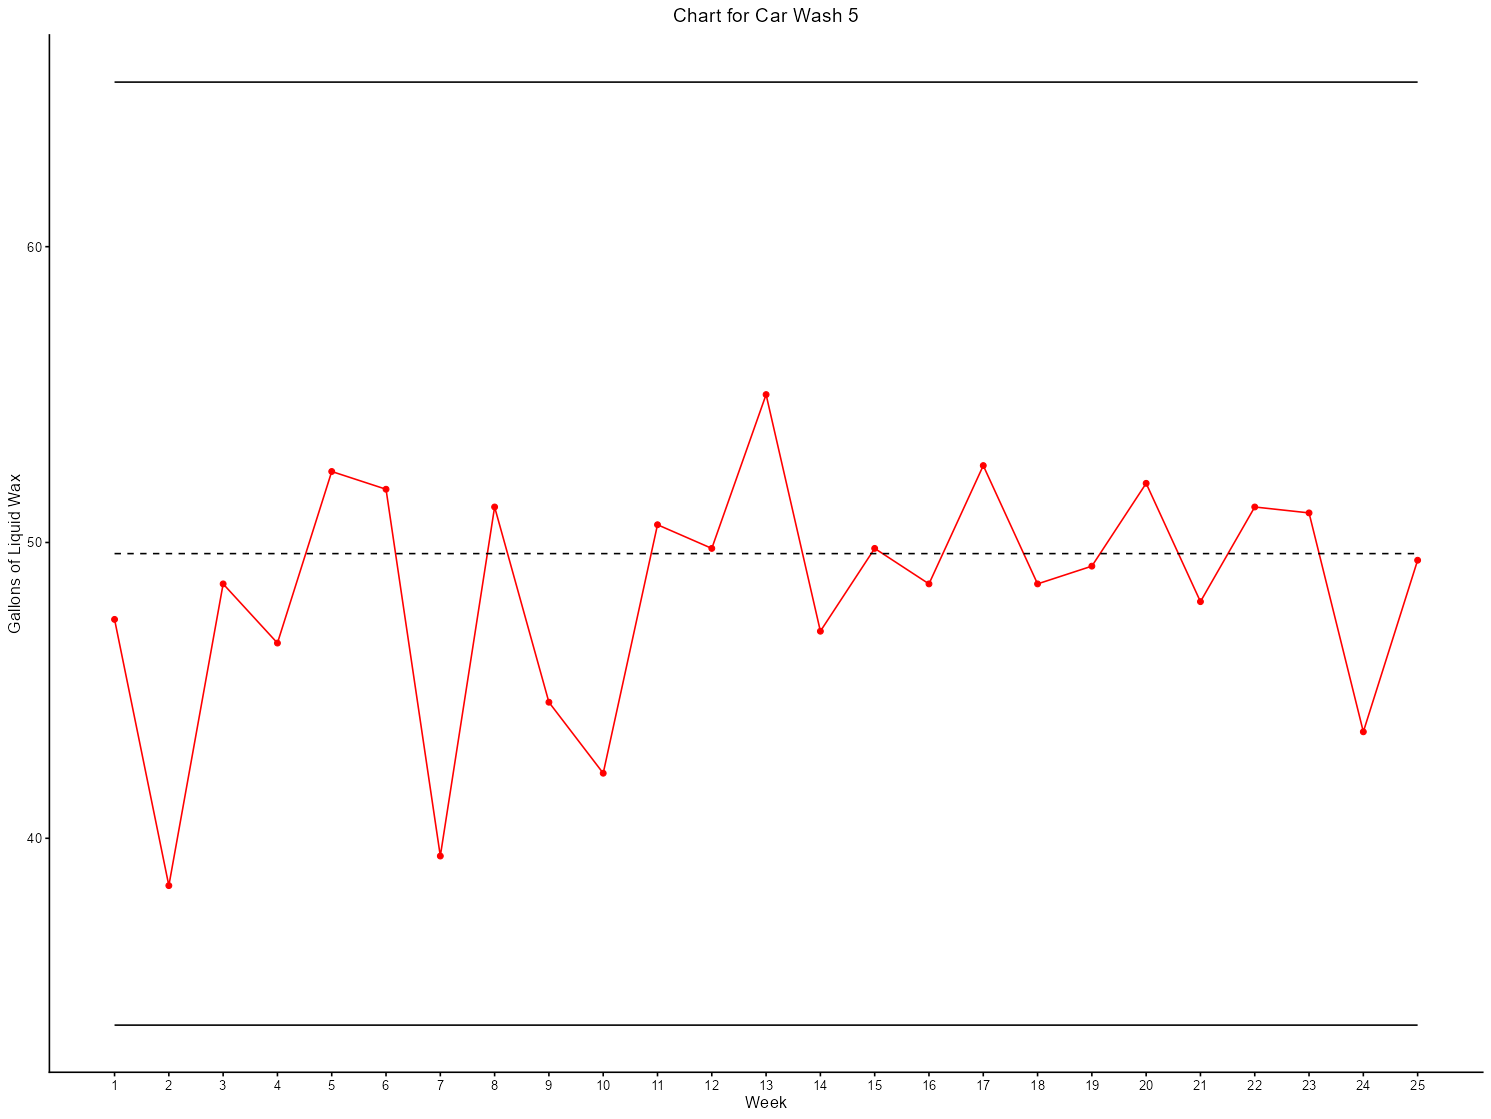

In [23]:
## Plot Phase II Charts ##

cfes2 <- vector('list',length=5)

for(i in 1:5){
  
  limits <- cfes[[i]]$Limits
  
  center_line <- cfes[[i]]$Center
  
  df <- samp_list2[[i]]
  
  p2_chart <- df |>
    ggplot(aes(x=Week,y=Means)) +
    geom_point(color='red') + geom_line(color='red') +
    geom_line(aes(y=limits[2]),color='black') +
    geom_line(aes(y=limits[1]),color='black') +
    geom_line(aes(y=center_line),color='black',linetype='dashed') +
    labs(x = "Week", y = "Gallons of Liquid Wax",
         title = paste("Chart for Car Wash ",unique(df$CarWashID),sep="")) +
    theme_classic()  +
    theme(plot.title=element_text(hjust=0.50)) +
    scale_x_continuous(breaks = seq(1,25))
  
  info <- list(Violations = df |>
                 filter(Means > limits[2] | Means < limits[1]) |>
                 select(Week))
  
  cfes2[[i]] <- info
  
  print(p2_chart)
  
}

### Checking each stream for violations

Unlike Boyd's GCC, we don't need any extra filtering step to find the culprit — each stream's chart already tells us directly whether *it* went out of control.

In [24]:
## So how can we know if any of our points are OOC? ##

cfes2[[1]]

$Violations
# A tibble: 10 × 1
    Week
   <int>
 1     2
 2     3
 3     4
 4     5
 5     8
 6    14
 7    18
 8    19
 9    20
10    23


In [25]:
cfes2[[2]]

$Violations
# A tibble: 0 × 1
# ℹ 1 variable: Week <int>


In [26]:
cfes2[[3]]

$Violations
# A tibble: 0 × 1
# ℹ 1 variable: Week <int>


In [27]:
cfes2[[4]]

$Violations
# A tibble: 0 × 1
# ℹ 1 variable: Week <int>


In [28]:
cfes2[[5]]

$Violations
# A tibble: 0 × 1
# ℹ 1 variable: Week <int>


Same conclusion as Boyd's GCC — Car Wash 1 is the only stream out of control — but this time we got there directly from the per-stream charts themselves, with no extra digging required.

## Final Remarks

Both approaches answered the same underlying question — is our fleet of car washes behaving consistently? — but they got there very differently:

| | Boyd's GCC | Control Chart for Each Stream |
|---|---|---|
| Plotting statistic | Min/max mean across all streams | Each stream's own mean |
| Identifies *which* stream is OOC directly? | No — requires a follow-up filtering step | Yes |
| Scales well to many streams? | Degrades as $s$ grows | Scales naturally (just more charts) |
| Extra design step | None beyond standard $\bar{X}$/$R$ | Requires an inter-stream correlation adjustment to $L$ |

In an era where control charts are built and monitored by computer as a matter of course, the per-stream approach's traditional downside — "too many charts to maintain" — mostly disappears, which is exactly the argument Mences et al. (2008) make. That's a useful lesson beyond MSP charts specifically: some of the classical arguments for aggregating information into a single statistic were really arguments about the *cost of computation and plotting*, not the statistics themselves — and that cost has changed a lot since 1950.